In [1]:
# bibliotecas
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'
transform = transforms.Compose([transforms.ToTensor()]) # transformação das imagens

In [2]:
# Carregando dados
train_data = datasets.CIFAR10(root='/content/cifar10', train=True, download=True, transform=transform)

test_data = datasets.CIFAR10(root='/content/cifar10', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [29:27<00:00, 96.4kB/s]


In [3]:
# Criando os DataLoaders
train_loader = DataLoader(train_data, batch_size=128, shuffle=True) # treino

test_loader = DataLoader(test_data, batch_size=128, shuffle=False) # teste

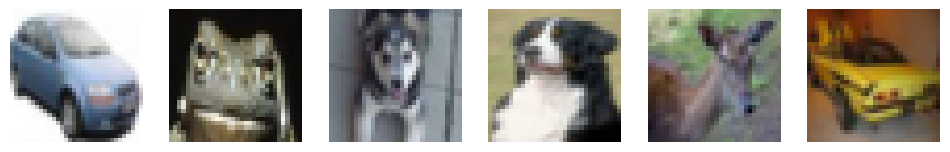

In [4]:
# Visualizar algumas imagens originais
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(12, 3)) # separa em 6 imagens de 12x3
for i in range(6):
    img = images[i].permute(1, 2, 0) # troca a ordem das dimensões
    axes[i].imshow(img)
    axes[i].axis('off')
plt.show() # exibe

In [5]:
def adicionar_ruido(images, intensidade=0.2): # Função para adicionar ruído
    ruido = intensidade * torch.randn_like(images) # itensidade
    noisy_images = images + ruido # adicona ruido na imagem
    noisy_images = torch.clamp(noisy_images,0, 1)
    return noisy_images # retorna

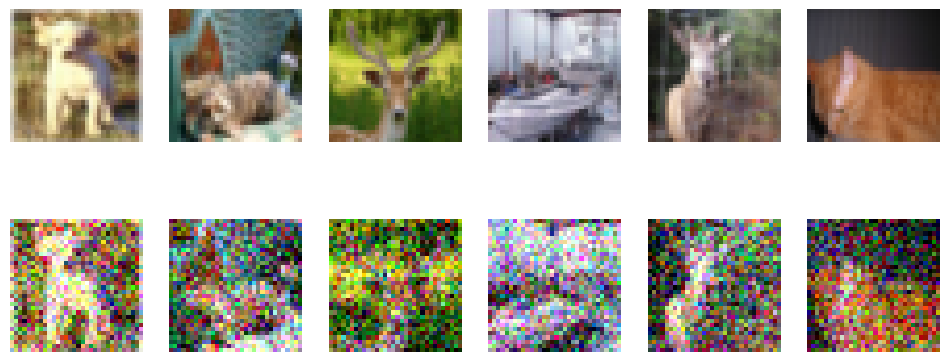

In [6]:
# Mostra a imagem original e a imagem com ruído
images, labels = next(iter(train_loader))

noisy_images = adicionar_ruido(images, intensidade=0.2) # adicionando ruido funcao

fig, axes = plt.subplots(2, 6, figsize=(12, 5))

for i in range(6):

    original = images[i].permute(1, 2, 0)

    noisy = noisy_images[i].permute(1, 2, 0)

    axes[0, i].imshow(original) # original
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy) # com ruido
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Com ruído")

plt.show()

In [7]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential( # recebe a imagem e vai diminuindo seu tamanho enquanto aumenta a quantidade de características detectadas
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU())

        self.decoder = nn.Sequential( # o decordificador faz o contrario do enconder ele tenta recontruir a imagem
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid())

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
model = Autoencoder().to(device) # cria o modelo
criterion = nn.MSELoss() # funcao de perda
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # otimizador

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [9]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    # percorre os batches do conjunto de treino
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = adicionar_ruido(images, intensidade=0.2)

        noisy_images = noisy_images.to(device) # adiciona ruído nas imagens para o modelo tentar remover

        optimizer.zero_grad()
        # passa as imagens com ruído pelo autoencoder
        # e gera as imagens reconstruídas
        reconstructed = model(noisy_images)

        loss = criterion(reconstructed, images) # compara a imagem reconstruída com a imagem original
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader) # calcula a média das perdas da época
    train_losses.append(average_loss) # salva a perda média para usar depois no gráfico

    print(f"Época {epoch + 1}/{num_epochs} "f"- Loss: {average_loss:.4f}")

Época 1/20 - Loss: 0.0188
Época 2/20 - Loss: 0.0090
Época 3/20 - Loss: 0.0077
Época 4/20 - Loss: 0.0067
Época 5/20 - Loss: 0.0061
Época 6/20 - Loss: 0.0058
Época 7/20 - Loss: 0.0056
Época 8/20 - Loss: 0.0054
Época 9/20 - Loss: 0.0052
Época 10/20 - Loss: 0.0051
Época 11/20 - Loss: 0.0050
Época 12/20 - Loss: 0.0049
Época 13/20 - Loss: 0.0048
Época 14/20 - Loss: 0.0048
Época 15/20 - Loss: 0.0047
Época 16/20 - Loss: 0.0046
Época 17/20 - Loss: 0.0046
Época 18/20 - Loss: 0.0045
Época 19/20 - Loss: 0.0045
Época 20/20 - Loss: 0.0045


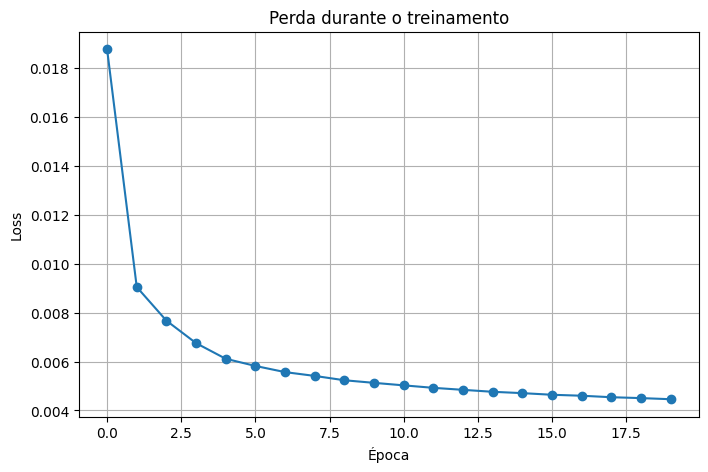

In [10]:
plt.figure(figsize=(8, 5)) # Gráfico da perda
plt.plot(train_losses, marker='o')
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Perda durante o treinamento")
plt.grid()
plt.show()

In [11]:
model.eval() # testando modelo

images, labels = next(iter(test_loader))

images = images.to(device)
noisy_images = adicionar_ruido(images, intensidade=0.2) # adicionando ruido na imagem

with torch.no_grad():
  reconstructed = model( noisy_images)

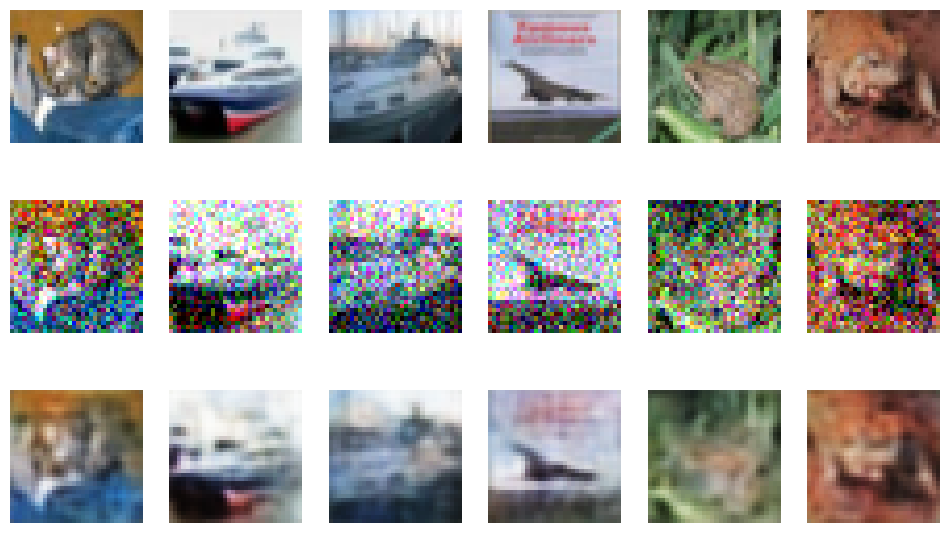

In [12]:
# Comparando os resultados
images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed = reconstructed.cpu()
fig, axes = plt.subplots(3, 6, figsize=(12, 7))

for i in range(6):
    original = images[i].permute(1, 2, 0) # invertendo as dimensoes da imagem original

    noisy = noisy_images[i].permute(1, 2, 0) # mesma coisa só que agora com a do ruido

    recovered = reconstructed[i].permute(1, 2, 0) # mesma coisa, só que agora com a reconstruida

    axes[0, i].imshow(original)
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy)
    axes[1, i].axis('off')

    axes[2, i].imshow(recovered)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Com ruído")
axes[2, 0].set_ylabel("Reconstruída")

plt.show()

In [13]:
# calculando o erro no conjunto de teste
model.eval()
test_loss = 0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        noisy_images = adicionar_ruido(images, intensidade=0.2)

        reconstructed = model(noisy_images)
        loss = criterion(reconstructed, images)
        test_loss += loss.item()
test_loss = test_loss / len(test_loader)

print(f"Loss no conjunto de teste: {test_loss:.4f}")

Loss no conjunto de teste: 0.0044
